# EDA de Pricing — Lubrax

Auditoria de sinais, classificação dos movimentos, reconciliação financeira e preparação de dados para pricing e clusterização. As classificações de devolução são hipóteses analíticas até validação do negócio.

In [1]:
from pathlib import Path
import importlib.metadata as metadata
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

REQUIRED = ['pandas', 'numpy', 'openpyxl', 'matplotlib', 'seaborn']
display(pd.DataFrame({'biblioteca': REQUIRED, 'versao': [metadata.version(x) for x in REQUIRED]}))
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
sns.set_theme(style='whitegrid', palette='deep')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
EXCEL_PATH = ROOT / 'inputs' / 'raw' / 'base_Lubrax_origem.xlsx'
CACHE_PATH = ROOT / 'outputs' / 'cache' / 'base_Lubrax_origem.pkl'
OUTPUT_DIR = ROOT / 'outputs' / '1. EDA'
SHEET_NAME = 'Base Exportavel (1)'
DATE_COL = 'Data Venda'
MONEY_TOLERANCE = 0.01
EPS = 1e-9
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
assert EXCEL_PATH.exists(), f'Arquivo não encontrado: {EXCEL_PATH}'

,biblioteca,versao
0,pandas,3.0.5
1,numpy,2.5.3
2,openpyxl,3.1.5
3,matplotlib,3.11.1
4,seaborn,0.13.2


## 1. Leitura eficiente e perfil básico

In [2]:
def cache_is_current(source, cache):
    return cache.exists() and cache.stat().st_mtime_ns >= source.stat().st_mtime_ns

start = time.perf_counter()
if cache_is_current(EXCEL_PATH, CACHE_PATH):
    df = pd.read_pickle(CACHE_PATH)
    read_source = 'cache Pickle'
else:
    df = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME, engine='openpyxl')
    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    df.to_pickle(CACHE_PATH)
    read_source = 'Excel; cache criado'

df[DATE_COL] = pd.to_datetime(df[DATE_COL], dayfirst=True, errors='coerce')
elapsed = time.perf_counter() - start
profile = pd.DataFrame({
    'fonte': [read_source], 'linhas': [len(df)], 'colunas': [df.shape[1]],
    'data_min': [df[DATE_COL].min()], 'data_max': [df[DATE_COL].max()],
    'memoria_mb': [df.memory_usage(deep=True).sum() / 2**20],
    'leitura_segundos': [elapsed],
})
display(profile)
display(df.head(3))

,fonte,linhas,colunas,data_min,data_max,memoria_mb,leitura_segundos
0,cache Pickle,253624,110,2023-01-01,2026-09-01,618.04569,0.371158


,Index,Data Venda,Canal Owner,Canal,DIR,GE,2º Nivel,3º Nível,Nome Cliente,Código Cliente,CNPJ Cliente,nome_atividade,setor_industrial_cliente,País Cliente,Estado Cliente,Município Cliente,incoterms,Código Base,Nome Base,Estado Base,Municipio Base,Código Material,Material,Prod - Tipo de Base,Tipo de Produtos (Básicos),PRODUTO_NVL4,Prod - Embalagem,Prod - Categoria simples,Prod - Família de Produtos,Segmentação B2B,Clientes Risel?,prod_categoria_1,prod_categoria_3,Aplicação,prod_categoria_3.1,% Dif CPV Contab vs Rep,.CPV Contábil,.CPV Reposição,.CT e LM com Impostos,.CT e LM sem Impostos,.Cálculo,.Efeito Estoque,.Efeito Estoque Negativo,.Efeito Estoque Positivo,.ICMS,.Impostos CT e LM,.Impostos Nexus,.LB Contábil,.LB Rep + Efeito Estoque,.LB Reposição,.Nexus com Impostos,.Outros Impostos,.PIS/COFINS,.Receita Bruta,.Receita Liquida,.Receita Liquida - CT e LM,.Receita Liquida - Produto,.Receita Liquida sem Encargos e Frete,.Receita Líquida - Nexus,.Receita de Encargos,.Receita de Frete,.Total Impostos,.Volume,.rec teste,CPV Contab vs Rep,CPV Contábil por M³,CPV Fechamento,CPV Parc,CPV Rep,CPV Rep por M³,CT,Contagem de Sellin,Dif Total CPV Rep vs CPV Fechamento,Frete,Index.1,KPI,LB Contábil,LB Contábil + CTLM,LB Rep + Efeito Estoque + Encargos,LB Reposição,LB Reposição + CTLM,LM,Margem Contábil + CTLM,Margem Reposição + CTLM,Margem Reposição Unitaria,Nexus,Preço MedNF,Prod - Código,Qtd de Clientes,Receita Bruta,Receita Liquida + CT e LM,Receita Liquida por m³,Receita líquida,Repasse ICMS,Repasse ICMS Total,Total CT LM,Volume,cliente_risel,ct_com_imposto,ctlm_com_imposto,desconto,encargos,faturamento_real,lm_com_imposto,nx,nx_com_impostos,percen_receita_bruta,prod_litragem,receita_bruta_total,repasse_pis_confis
0,1,2023-01-01,Canal Direto,COMNAC,B2B,COMNAC,B2BCO,B2BCOZ01,BRITAMIX INDUSTRIA E COMERCIO DE CA,1036111,21821738000190,Lubrificantes,Consumidor,BR,Mato Grosso,NOBRES,FOB - Rodoviário,5096,BAIBA Base de Cuiabá,Mato Grosso,340,1000343,LUBRAX GL 5 140 - TB 200 L,Mineral,Lubrificante Acabado,Óleo Lubrificante Automotivo,TAMBOR 200L,DRIVELINE,GL 5,MINERAÇÃO,Não,Óleo Lubrificante Driveline,Driveline Engrenagens Convencional,Driveline Engrenagens,Driveline Engrenagens Convencional,0.064,-4552.26,-4278.78,0,0,1,-273.48,-273.48,0.0,0.0,0,0,2490.43,246.52,520.0,0,0.0,-717.85,7760.54,7042.69,0,7042.69,4798.78,0,2243.91,0.0,-717.85,0.40,0,683.70,11381.0,4552.26,0.0,4278.78,10697,0,1,-273.48,0.0,1,0.40,2490.43,2490.43,2490.43,520.0,520.0,0,6226.08,1300.0,1300.00,0,19.40,1000343,1,7760.54,7042.69,17606.73,7042.69,0.0,0.0,0,0.40,0,0,0,3479.64,2243.91,4798.78,0,0,0,0.09,200.00,7760.54,717.85
1,2,2023-01-01,Canal Direto,COMNAC,B2B,COMNAC,B2BCO,B2BCOZ01,BRITAMIX INDUSTRIA E COMERCIO DE CA,1036111,21821738000190,Lubrificantes,Consumidor,BR,Mato Grosso,NOBRES,FOB - Rodoviário,5096,BAIBA Base de Cuiabá,Mato Grosso,340,1000684,LUBRAX LITH SM 2 - BL 20 K,Mineral,Lubrificante Acabado,Graxa Industrial,BALDE 20KG,GRAXA,LITH SM,MINERAÇÃO,Não,Graxa Lubrificante,Graxa Industrial Convencional,Graxa Industrial,Graxa Industrial Convencional,0.041,-927.06,-890.56,0,0,1,-36.50,-36.50,0.0,0.0,0,0,449.13,25.90,62.4,0,0.0,-140.27,1516.46,1376.19,0,1376.19,952.96,0,423.23,0.0,-140.27,0.05,0,760.42,19314.0,927.06,0.0,890.56,18553,0,1,-36.50,0.0,1,0.05,449.13,449.13,449.13,62.4,62.4,0,9356.88,1300.0,1312.63,0,31.90,1000684,1,1516.46,1376.19,28670.63,1376.19,0.0,0.0,0,0.05,0,0,0,484.34,423.23,952.96,0,0,0,0.02,23.77,1516.46,140.27
2,3,2023-01-01,Canal Direto,COMNAC,B2B,COMNAC,B2BCO,B2BCOZ01,BRITAMIX INDUSTRIA E COMERCIO DE CA,1036111,21821738000190,Lubrificantes,Consumidor,BR,Mato Grosso,NOBRES,FOB - Rodoviário,5096,BAIBA Base de Cuiabá,Mato Grosso,340,1000803,LUBRAX HYDRA XP 32 - BL 20 L,Mineral,Lubrificante Acabado,Óleo Lubrificante Industrial,BALDE 20L,INDUSTRIAL,HYDRA XP,MINERAÇÃO,Não,Óleo Lubrificante Industrial,Industrial Hidráulico Convencional,Industrial Hidráulico,Industrial Hidráulico Convencional,0.172,-349.52,-298.30,0,0,1,-51.22,-51.22,0.0,0.0,0,0,185.

In [3]:
quality = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    'nulos_pct': df.isna().mean().mul(100),
    'unicos': df.nunique(dropna=True),
})
quality['constante'] = quality['unicos'].le(1)
quality = quality.sort_values(['constante', 'nulos_pct'], ascending=[False, False])
display(quality.style.format({'nulos_pct': '{:.2f}%'}))
print('Colunas constantes:', quality['constante'].sum())
print('Colunas totalmente nulas:', quality['nulos_pct'].eq(100).sum())

,tipo,nulos,nulos_pct,unicos,constante
Canal Owner,str,0,0.00%,1,True
Canal,str,0,0.00%,1,True
DIR,str,0,0.00%,1,True
GE,str,0,0.00%,1,True
nome_atividade,str,0,0.00%,1,True
País Cliente,str,0,0.00%,1,True
.CT e LM com Impostos,int64,0,0.00%,1,True
.CT e LM sem Impostos,int64,0,0.00%,1,True
.Cálculo,int64,0,0.00%,1,True
.Impostos CT e LM,int64,0,0.00%,1,True


Colunas constantes: 26
Colunas totalmente nulas: 0


### Conclusão da etapa

A base tem **253.624 registros**, **110 colunas** e cobre janeiro/2023 a setembro/2026. O cache reduziu a leitura para cerca de meio segundo, mas o DataFrame ocupa aproximadamente 618 MB em memória. Não há colunas totalmente nulas, porém 26 são constantes e não acrescentam informação a análises de pricing ou ao K-Means. A competência de setembro/2026 é parcial e não deve ser comparada diretamente com meses completos.

## 2. Métricas canônicas e classificação dos movimentos

A classificação é conservadora: somente movimentos com sinais coerentes são chamados de venda ou devolução provável.

In [4]:
CANONICAL = {
    'volume': 'Volume',
    'receita_bruta': '.Receita Bruta',
    'receita_liquida': 'Receita líquida',
    'cpv_reposicao': 'CPV Rep',
    'cpv_fechamento': 'CPV Fechamento',
    'lucro_reposicao': 'LB Reposição',
    'lucro_contabil': 'LB Contábil',
    'frete': 'Frete',
    'encargos': 'encargos',
    'desconto': 'desconto',
}
missing = [column for column in CANONICAL.values() if column not in df.columns]
assert not missing, f'Colunas canônicas ausentes: {missing}'

for alias, column in CANONICAL.items():
    df[f'_eda_{alias}'] = pd.to_numeric(df[column], errors='coerce')

v = df['_eda_volume']
rl = df['_eda_receita_liquida']
cpv = df['_eda_cpv_reposicao']
core_financial = [f'_eda_{x}' for x in ['receita_bruta','receita_liquida','cpv_reposicao','lucro_reposicao','frete','encargos']]
has_financial = df[core_financial].abs().gt(EPS).any(axis=1)

conditions = [
    v.gt(EPS) & rl.gt(EPS),
    v.lt(-EPS) & rl.lt(-EPS) & cpv.lt(-EPS),
    v.abs().le(EPS) & has_financial,
    v.abs().le(EPS) & ~has_financial,
]
labels = ['VENDA', 'DEVOLUCAO_PROVAVEL', 'AJUSTE_SEM_VOLUME', 'SEM_MOVIMENTO']
df['tipo_movimento_eda'] = pd.Categorical(
    np.select(conditions, labels, default='SINAL_INCONSISTENTE'),
    categories=labels + ['SINAL_INCONSISTENTE'],
)

movement_summary = (df.groupby('tipo_movimento_eda', observed=False)
    .agg(registros=('tipo_movimento_eda','size'), volume=('_eda_volume','sum'),
         receita_liquida=('_eda_receita_liquida','sum'), cpv_reposicao=('_eda_cpv_reposicao','sum'))
    .reset_index())
movement_summary['registros_pct'] = movement_summary['registros'] / len(df) * 100
display(movement_summary.style.format({'registros_pct':'{:.2f}%'}))
movement_summary.to_csv(OUTPUT_DIR / 'classificacao_movimentos.csv', index=False, encoding='utf-8-sig')

,tipo_movimento_eda,registros,volume,receita_liquida,cpv_reposicao,registros_pct
0,VENDA,245456,131463.690000,1513319661.840000,1173805105.680000,96.78%
1,DEVOLUCAO_PROVAVEL,2068,-1068.780000,-13788284.670000,-9849655.120000,0.82%
2,AJUSTE_SEM_VOLUME,1292,0.000000,-1646702.440000,23191.790000,0.51%
3,SEM_MOVIMENTO,4767,0.000000,0.000000,0.000000,1.88%
4,SINAL_INCONSISTENTE,41,12.310000,-107473.780000,104902.490000,0.02%


### Conclusão da etapa

A classificação separou **245.456 vendas (96,78%)**, **2.068 devoluções prováveis (0,82%)**, **1.292 ajustes sem volume (0,51%)**, **4.767 registros sem movimento (1,88%)** e **41 inconsistências de sinal (0,02%)**. Essa separação impede que devoluções e ajustes distorçam preços unitários. O termo “devolução provável” continua dependendo da confirmação por tipo de documento ou natureza da operação.

## 3. Auditoria de sinais e casos para investigação

,metrica,negativo,zero,positivo,nulos
0,volume,2075,6059,245490,0
1,receita_bruta,2816,5255,245553,0
2,receita_liquida,2927,4984,245713,0
3,cpv_reposicao,2275,5642,245707,0
4,cpv_fechamento,2791,8326,242507,0
5,lucro_reposicao,5141,5061,243422,0
6,lucro_contabil,9580,3692,240352,0
7,frete,1996,45543,206085,0
8,encargos,11452,17905,224267,0
9,desconto,4161,13074,236389,0


col_0,negativo,zero,positivo,All
row_0,,,,
negativo,2069,0,6,2075
zero,824,4984,251,6059
positivo,34,0,245456,245490
All,2927,4984,245713,253624


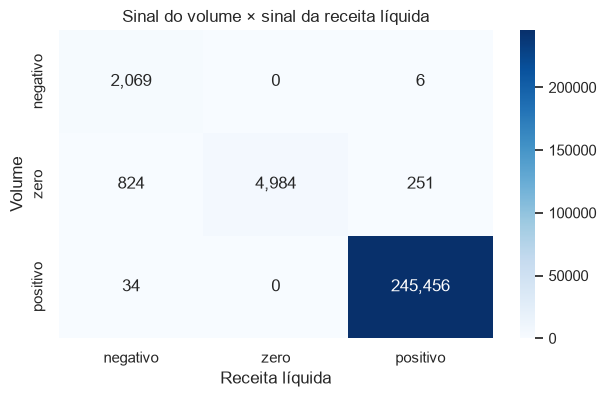

In [5]:
def sign_label(series):
    return pd.Categorical(
        np.select([series.lt(-EPS), series.gt(EPS)], ['negativo','positivo'], default='zero'),
        categories=['negativo','zero','positivo'], ordered=True,
    )

sign_rows = []
for alias in CANONICAL:
    values = df[f'_eda_{alias}']
    counts = pd.Series(sign_label(values)).value_counts(sort=False)
    sign_rows.append({'metrica': alias, **counts.to_dict(), 'nulos': int(values.isna().sum())})
sign_summary = pd.DataFrame(sign_rows).fillna(0)
display(sign_summary)

sign_matrix = pd.crosstab(sign_label(v), sign_label(rl), margins=True)
display(sign_matrix)
plt.figure(figsize=(7,4))
sns.heatmap(sign_matrix.iloc[:-1,:-1], annot=True, fmt=',', cmap='Blues')
plt.title('Sinal do volume × sinal da receita líquida')
plt.xlabel('Receita líquida'); plt.ylabel('Volume'); plt.show()

,Data Venda,Código Cliente,Nome Cliente,Código Material,Material,Volume,.Receita Bruta,Receita líquida,CPV Rep,CPV Fechamento,LB Reposição,LB Contábil,Frete,encargos,desconto,tipo_movimento_eda
32187,2023-06-01,55930,EXPRESSO VERA CRUZ LTDA,1014421,LUBRAX GOLD XP 75W80 - BL 20 L,0.04,1165.88,-811.28,738.80,763.90,99.98,-1575.18,13.14,-1663.20,1152.90,SINAL_INCONSISTENTE
34252,2023-06-01,1080973,AMBIPAR ENVIRONMENTAL NORDESTE LTDA,1001981,LUBRAX FLUIDO P/ FREIOS ESP - CX40F1/2L,0.02,624.22,-20.78,433.48,469.98,5.92,-490.76,6.95,-467.13,260.71,SINAL_INCONSISTENTE
37235,2023-07-01,10727,CFL CONSTRUTORA FERREIRA LIMA LTDA,1011554,LUBRAX TECNO 15W40 - CX24F1L,0.05,1045.66,-3317.88,455.50,425.28,286.64,-3743.16,22.85,-4082.87,185.54,SINAL_INCONSISTENTE
40584,2023-07-01,21628,TANAC SA,1001114,LUBRAX GEAR 460 - BL 20 L,0.02,341.22,-1947.26,206.49,249.72,36.00,-2196.98,10.19,-2199.94,204.62,SINAL_INCONSISTENTE
44349,2023-08-01,1127284,CESCONETTO INDUSTRIA E COMERCIO DE,1007537,LUBRAX AVANTE 10W40 - BB20L,0.06,1731.90,-262.55,1043.79,1188.12,136.65,-1450.67,71.17,-1514.16,649.65,SINAL_INCONSISTENTE
44477,2023-08-01,674,CIBRAFERTIL COMPANHIA BRASILEIRA DE,1000670,LUBRAX LITH EP 2 - BL 20 K,0.04,1063.50,-587.03,652.02,658.84,75.19,-1245.87,41.34,-1355.58,309.69,SINAL_INCONSISTENTE
45247,2023-08-01,1023984,PELICANO CONSTRUCOES S.A.,1002282,LUBRAX HYDRA XP 68 - TB 200 L,0.20,3093.31,-242.53,1680.83,1888.45,440.00,-2130.98,87.02,-2450.38,1208.26,SINAL_INCONSISTENTE
45248,2023-08-01,1023984,PELICANO CONSTRUCOES S.A.,1002396,LUBRAX TOP TURBO - TB200L,0.20,3611.63,-3113.54,2050.78,2032.05,440.00,-5145.59,87.02,-5691.34,911.90,SINAL_INCONSISTENTE
45922,2023-08-01,1004023,TRANSPORTADORA TURISTICA SUZANO LTD,1000743,LUBRAX LITHPLUS EP 2 - BL 20 K,0.02,646.95,-467.52,387.23,424.85,57.40,-892.37,15.39,-927.54,247.60,SINAL_INCONSISTENTE
49812,2023-09-01,108052,CORPVS - CORPO DE VIGILANTES PARTIC,1024151,LUBRAX MOTO 4T 20W50 - CXC24F1L,-0.12,1050.53,722.72,-1185.73,-1276.55,1993.95,1999.27,-39.66,-45.84,-2816.32,SINAL_INCONSISTENTE


Registros para investigação: 41


tipo_movimento_eda,VENDA,DEVOLUCAO_PROVAVEL,AJUSTE_SEM_VOLUME,SEM_MOVIMENTO,SINAL_INCONSISTENTE
mes,,,,,
2025-04,5328,38,15,46,0
2025-05,6298,40,9,48,0
2025-06,5764,42,39,48,0
2025-07,6281,61,33,42,0
2025-08,6250,46,12,39,0
2025-09,6328,46,27,48,0
2025-10,6703,31,9,37,0
2025-11,5798,37,44,42,0
2025-12,5201,59,23,40,0


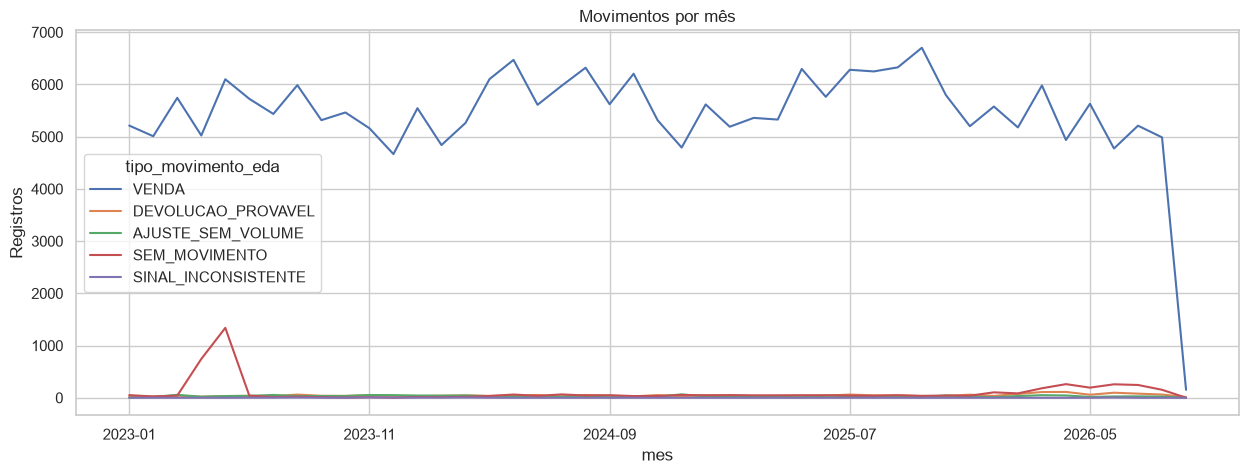

In [6]:
KEYS = [DATE_COL, 'Código Cliente', 'Nome Cliente', 'Código Material', 'Material']
AUDIT_COLS = KEYS + list(CANONICAL.values()) + ['tipo_movimento_eda']
anomalies = df.loc[df['tipo_movimento_eda'].eq('SINAL_INCONSISTENTE'), AUDIT_COLS].copy()
display(anomalies.head(30))
print(f'Registros para investigação: {len(anomalies):,}')
anomalies.to_csv(OUTPUT_DIR / 'movimentos_sinal_inconsistente.csv', index=False, encoding='utf-8-sig')

movement_month = (df.assign(mes=df[DATE_COL].dt.to_period('M').astype(str))
    .groupby(['mes','tipo_movimento_eda'], observed=True).size().unstack(fill_value=0))
display(movement_month.tail(18))
movement_month.plot(figsize=(15,5), title='Movimentos por mês')
plt.ylabel('Registros'); plt.show()

### Conclusão da etapa

Valores negativos não são automaticamente erros. Em 2.069 dos 2.075 volumes negativos, a receita líquida também é negativa, comportamento coerente com estorno ou devolução. Já movimentos de volume zero com valores financeiros indicam ajustes sem movimentação física. Os 41 casos restantes combinam sinais incompatíveis e foram exportados para investigação individual.

## 4. Reconciliação financeira

Cada regra é avaliada por linha com tolerância de R$ 0,01. Diferenças acima da tolerância são exportadas para auditoria.

In [7]:
num = lambda column: pd.to_numeric(df[column], errors='coerce')
RECONCILIATIONS = {
    'volume_duplicado': num('.Volume') - num('Volume'),
    'receita_liquida_duplicada': num('.Receita Liquida') - num('Receita líquida'),
    'cpv_reposicao_sinal': num('.CPV Reposição') + num('CPV Rep'),
    'lb_reposicao_duplicado': num('.LB Reposição') - num('LB Reposição'),
    'frete_duplicado': num('.Receita de Frete') - num('Frete'),
    'encargos_duplicado': num('.Receita de Encargos') - num('encargos'),
    'receita_liquida_formula': num('.Receita Liquida') - (num('.Receita Bruta') + num('.Total Impostos')),
    'receita_sem_frete_encargos': num('.Receita Liquida sem Encargos e Frete ') - (num('.Receita Liquida') - num('encargos') - num('Frete')),
    'lb_contabil_formula': num('.LB Contábil') - (num('.Receita Liquida') + num('.CPV Contábil')),
    'lb_reposicao_formula': num('.LB Reposição') - (num('.Receita Liquida sem Encargos e Frete ') + num('.CPV Reposição')),
    'efeito_estoque_formula': num('.Efeito Estoque') - (num('.CPV Contábil') + num('CPV Rep')),
    'lb_rep_efeito_estoque': num('.LB Rep + Efeito Estoque') - (num('.LB Reposição') + num('.Efeito Estoque')),
    'lb_rep_efeito_encargos': num('LB Rep + Efeito Estoque + Encargos') - (num('.LB Rep + Efeito Estoque') + num('encargos')),
}

reconciliation_rows = []
failed_any = pd.Series(False, index=df.index)
for rule, difference in RECONCILIATIONS.items():
    valid = difference.notna()
    failed = valid & difference.abs().gt(MONEY_TOLERANCE)
    failed_any |= failed
    reconciliation_rows.append({
        'regra': rule, 'avaliados': int(valid.sum()), 'conciliados': int((valid & ~failed).sum()),
        'divergentes': int(failed.sum()), 'divergentes_pct': failed.sum()/max(valid.sum(),1)*100,
        'diferenca_abs_max': difference.abs().max(), 'diferenca_liquida': difference.sum(),
    })
reconciliation_summary = pd.DataFrame(reconciliation_rows)
display(reconciliation_summary.style.format({'divergentes_pct':'{:.4f}%','diferenca_abs_max':'{:,.2f}','diferenca_liquida':'{:,.2f}'}))
reconciliation_summary.to_csv(OUTPUT_DIR / 'resumo_reconciliacao.csv', index=False, encoding='utf-8-sig')
df.loc[failed_any, KEYS + list(CANONICAL.values())].to_csv(
    OUTPUT_DIR / 'divergencias_reconciliacao.csv', index=False, encoding='utf-8-sig'
)

,regra,avaliados,conciliados,divergentes,divergentes_pct,diferenca_abs_max,diferenca_liquida
0,volume_duplicado,253624,253624,0,0.0000%,0.00,0.00
1,receita_liquida_duplicada,253624,253624,0,0.0000%,0.00,0.00
2,cpv_reposicao_sinal,253624,253624,0,0.0000%,0.00,0.00
3,lb_reposicao_duplicado,253624,253624,0,0.0000%,0.00,0.00
4,frete_duplicado,253624,253624,0,0.0000%,0.00,0.00
5,encargos_duplicado,253624,253624,0,0.0000%,0.00,0.00
6,receita_liquida_formula,253624,253624,0,0.0000%,0.00,-0.00
7,receita_sem_frete_encargos,253624,253624,0,0.0000%,0.00,-0.00
8,lb_contabil_formula,253624,253624,0,0.0000%,0.00,-0.00
9,lb_reposicao_formula,253624,253624,0,0.0000%,0.00,0.00


In [8]:
SIMILAR_METRICS = [
    ('Receita Bruta', '.Receita Bruta', 1),
    ('CPV Fechamento', '.CPV Contábil', -1),
    ('LB Contábil', '.LB Contábil', 1),
]
similar_rows = []
for left, right, factor in SIMILAR_METRICS:
    difference = num(left) - factor * num(right)
    valid = difference.notna()
    equal = valid & difference.abs().le(MONEY_TOLERANCE)
    similar_rows.append({
        'metrica_a':left, 'metrica_b':right, 'fator_b':factor,
        'iguais':int(equal.sum()), 'avaliados':int(valid.sum()),
        'iguais_pct':equal.sum()/max(valid.sum(),1)*100,
        'diferenca_abs_max':difference.abs().max(), 'diferenca_liquida':difference.sum(),
    })
display(pd.DataFrame(similar_rows).style.format({'iguais_pct':'{:.2f}%','diferenca_abs_max':'{:,.2f}','diferenca_liquida':'{:,.2f}'}))

,metrica_a,metrica_b,fator_b,iguais,avaliados,iguais_pct,diferenca_abs_max,diferenca_liquida
0,Receita Bruta,.Receita Bruta,1,209010,253624,82.41%,"250,838.76","-70,367,585.43"
1,CPV Fechamento,.CPV Contábil,-1,249652,253624,98.43%,"1,358,287.06","-24,547,137.51"
2,LB Contábil,.LB Contábil,1,249652,253624,98.43%,"1,358,287.06","24,547,137.51"


### Conclusão da etapa

As 13 identidades financeiras testadas reconciliaram em 100% das linhas. Isso confirma, por exemplo, que `.CPV Reposição` é o mesmo CPV de reposição com sinal oposto e que as versões duplicadas de volume, receita líquida, frete e encargos são redundantes. Entretanto, nomes parecidos não garantem equivalência: `Receita Bruta` coincide com `.Receita Bruta` em apenas 82,41% das linhas, enquanto `CPV Fechamento` coincide com o inverso de `.CPV Contábil` em 98,43%. Essas colunas devem permanecer conceitualmente separadas até validação do negócio.

## 5. Métricas próprias de pricing

Preços unitários são calculados somente para vendas com volume positivo. Ajustes sem volume e devoluções permanecem disponíveis para reconciliação, mas não entram nas distribuições de preço.

In [9]:
eligible = df['tipo_movimento_eda'].eq('VENDA') & v.gt(EPS)
pricing = df.loc[eligible, KEYS + [
    'Canal', 'Estado Cliente', 'Estado Base', 'Segmentação B2B',
    'Prod - Família de Produtos', 'Prod - Embalagem', 'tipo_movimento_eda'
]].copy()
for alias in CANONICAL:
    pricing[alias] = df.loc[eligible, f'_eda_{alias}'].to_numpy()

pricing['preco_bruto_unitario'] = pricing['receita_bruta'] / pricing['volume']
pricing['preco_liquido_unitario'] = pricing['receita_liquida'] / pricing['volume']
pricing['cpv_unitario'] = pricing['cpv_reposicao'] / pricing['volume']
pricing['margem_unitaria'] = pricing['lucro_reposicao'] / pricing['volume']
pricing['margem_pct'] = pricing['lucro_reposicao'] / pricing['receita_liquida']
pricing['frete_unitario'] = pricing['frete'] / pricing['volume']
pricing['encargos_unitario'] = pricing['encargos'] / pricing['volume']
pricing['desconto_pct'] = pricing['desconto'] / pricing['receita_bruta'].replace(0, np.nan)
pricing.replace([np.inf,-np.inf], np.nan, inplace=True)

UNIT_METRICS = ['preco_bruto_unitario','preco_liquido_unitario','cpv_unitario','margem_unitaria','margem_pct','frete_unitario','encargos_unitario','desconto_pct']
display(pricing[UNIT_METRICS].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
preco_bruto_unitario,245456.0,19459.388646,9758.849755,-400976.500000,11171.058265,12801.650000,15229.987500,17280.000000,21276.525000,31779.250000,50508.650000,414493.000000
preco_liquido_unitario,245456.0,14530.603734,8183.083600,3.500000,8334.321020,9478.255357,11247.068056,12772.145833,15803.725000,23691.500000,38838.862500,963875.500000
cpv_unitario,245456.0,11156.799822,5592.684399,0.000000,6412.500000,7123.620000,8590.100000,9765.150000,11884.500000,18962.000000,29535.730000,249512.000000
margem_unitaria,245456.0,2426.398810,2349.256535,-32720.000000,-4.524977,599.948049,1385.375000,2000.000000,2907.250000,5710.000000,9171.041667,255900.000000
margem_pct,245456.0,0.139933,12.449792,-6167.571429,-0.000413,0.045012,0.106220,0.153761,0.213710,0.334942,0.418929,3.747317
frete_unitario,245456.0,484.395583,339.849622,0.000000,0.000000,0.000000,272.800000,494.425000,645.750000,1063.000000,1540.988521,6445.000000
encargos_unitario,245456.0,463.009520,4379.276592,-36777.380000,-0.200000,0.000000,183.675000,254.000000,395.850000,805.000000,4346.764063,943307.000000
desconto_pct,245456.0,0.280360,13.937293,-91.530437,0.000000,0.025548,0.152665,0.200932,0.321667,0.566937,0.724273,6865.500000


In [10]:
# Confirmar unidade de `Volume`: comparar com receita líquida ÷ 'Receita Liquida por m³'
receita_por_m3 = pd.to_numeric(df.loc[eligible, 'Receita Liquida por m³'], errors='coerce')
volume_implicito_m3 = pricing['receita_liquida'] / receita_por_m3.replace(0, np.nan)
razao_volume = (pricing['volume'] / volume_implicito_m3).replace([np.inf, -np.inf], np.nan).dropna()
pct_dentro_5pct = (razao_volume.sub(1).abs() <= 0.05).mean() * 100
print("Volume ÷ (Receita líquida ÷ 'Receita Liquida por m³') — deveria ser 1,0 se Volume estiver em m³:")
display(razao_volume.describe())
print(f"{pct_dentro_5pct:.1f}% das linhas ficam dentro de ±5% de 1,0")


Volume ÷ (Receita líquida ÷ 'Receita Liquida por m³') — deveria ser 1,0 se Volume estiver em m³:


count    245456.000000
mean          0.995313
std           0.034028
min           0.769231
25%           1.000000
50%           1.000000
75%           1.000000
max           1.250001
dtype: float64

94.0% das linhas ficam dentro de ±5% de 1,0


### Conclusão da etapa

O cálculo utiliza somente as 245.456 vendas elegíveis. O preço líquido unitário mediano é aproximadamente **R$ 12.772 por m³**, com P1 de 8.334 e P99 de 38.839; a margem percentual mediana é **15,38%**. **`Volume` está em m³** — confirmado acima: dividir a receita líquida pela coluna `Receita Liquida por m³` reproduz `Volume` quase exatamente (mediana da razão = 1,00; 94% das linhas dentro de ±5%). Médias simples por linha não devem ser usadas em consolidações: o preço correto do grupo é `soma(receita) / soma(volume)`.

## 6. Outliers e volumes muito pequenos

,indicador,registros,registros_pct
0,volume_muito_baixo,24600,10.02%
1,preco_outlier_global,4796,1.95%
2,margem_negativa,2469,1.01%


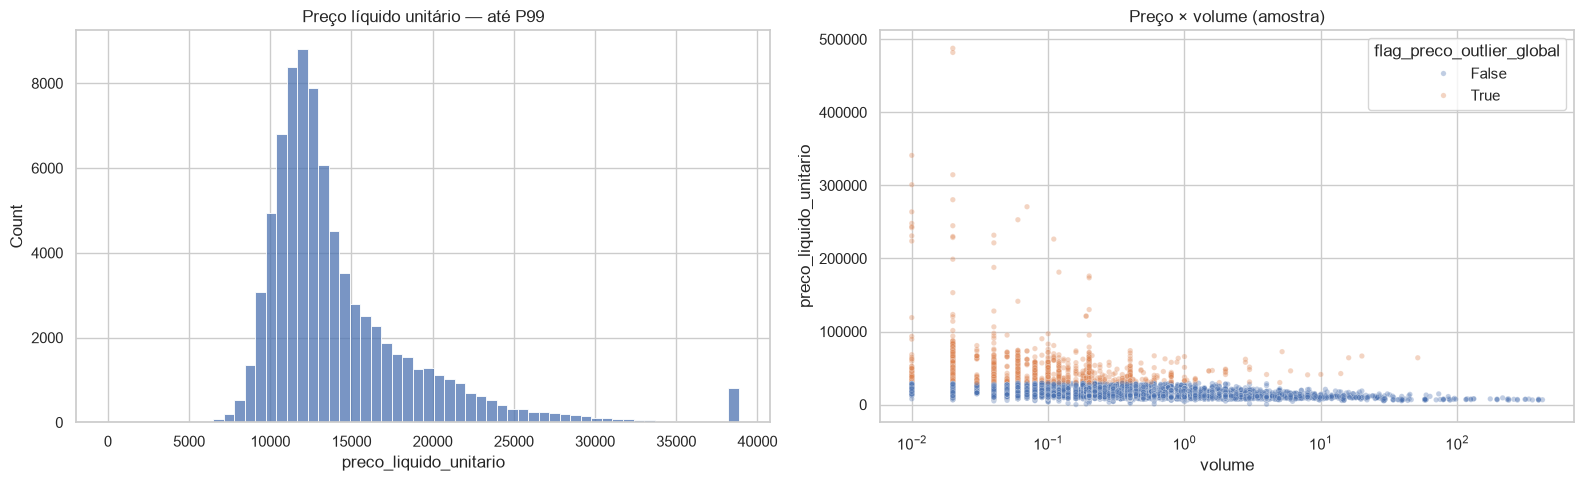

In [11]:
positive_volume_p01 = pricing['volume'].quantile(.01)
q1, q3 = pricing['preco_liquido_unitario'].quantile([.25,.75])
iqr = q3 - q1
lower, upper = q1 - 3*iqr, q3 + 3*iqr
pricing['flag_volume_muito_baixo'] = pricing['volume'].le(positive_volume_p01)
pricing['flag_preco_outlier_global'] = ~pricing['preco_liquido_unitario'].between(lower, upper)
pricing['flag_margem_negativa'] = pricing['margem_pct'].lt(0)

outlier_summary = pd.DataFrame({
    'indicador':['volume_muito_baixo','preco_outlier_global','margem_negativa'],
    'registros':[pricing['flag_volume_muito_baixo'].sum(),pricing['flag_preco_outlier_global'].sum(),pricing['flag_margem_negativa'].sum()],
})
outlier_summary['registros_pct'] = outlier_summary['registros']/len(pricing)*100
display(outlier_summary.style.format({'registros_pct':'{:.2f}%'}))

plot_sample = pricing.sample(min(80_000, len(pricing)), random_state=42)
fig, axes = plt.subplots(1,2,figsize=(16,5))
sns.histplot(plot_sample['preco_liquido_unitario'].clip(upper=pricing['preco_liquido_unitario'].quantile(.99)), bins=60, ax=axes[0])
axes[0].set_title('Preço líquido unitário — até P99')
sns.scatterplot(data=plot_sample, x='volume', y='preco_liquido_unitario', hue='flag_preco_outlier_global', alpha=.35, s=15, ax=axes[1])
axes[1].set(xscale='log', title='Preço × volume (amostra)')
plt.tight_layout(); plt.show()

### Conclusão da etapa

Foram sinalizados 4.796 preços fora do limite global de 3 IQR (1,95%) e 2.469 vendas com margem negativa (1,01%). A regra de volume muito baixo marcou 24.600 linhas (10,02%), mais que 1% porque muitos registros compartilham exatamente o valor do primeiro percentil. Esses registros não foram removidos: são flags para análise dentro de produto e embalagem, pois um limite global pode confundir diferenças legítimas de mix com anomalias.

## 7. Evolução temporal, devoluções e efeito de mix

,registros,volume,receita_liquida,lucro_reposicao,preco_liquido_ponderado,margem_pct_ponderada,taxa_devolucao_registros
mes,,,,,,,
2025-04-01,5328,3100.31,34216854.10,4670603.05,11036.591212,0.136500,0.007002
2025-05-01,6298,3741.53,40480823.63,5115156.82,10819.323547,0.126360,0.006255
2025-06-01,5764,3127.08,33700347.26,4565277.97,10776.937993,0.135467,0.007127
2025-07-01,6281,3843.27,39706861.69,5755443.56,10331.530621,0.144948,0.009506
2025-08-01,6250,3275.18,35475901.24,5147950.33,10831.740924,0.145111,0.007248
2025-09-01,6328,3383.87,36282488.15,5712445.07,10722.187362,0.157444,0.007133
2025-10-01,6703,3573.62,37426318.55,6652895.50,10472.942996,0.177760,0.004572
2025-11-01,5798,3504.24,35738688.36,5559137.19,10198.698822,0.155550,0.006249
2025-12-01,5201,2662.37,28599399.34,5479415.50,10742.082934,0.191592,0.011084


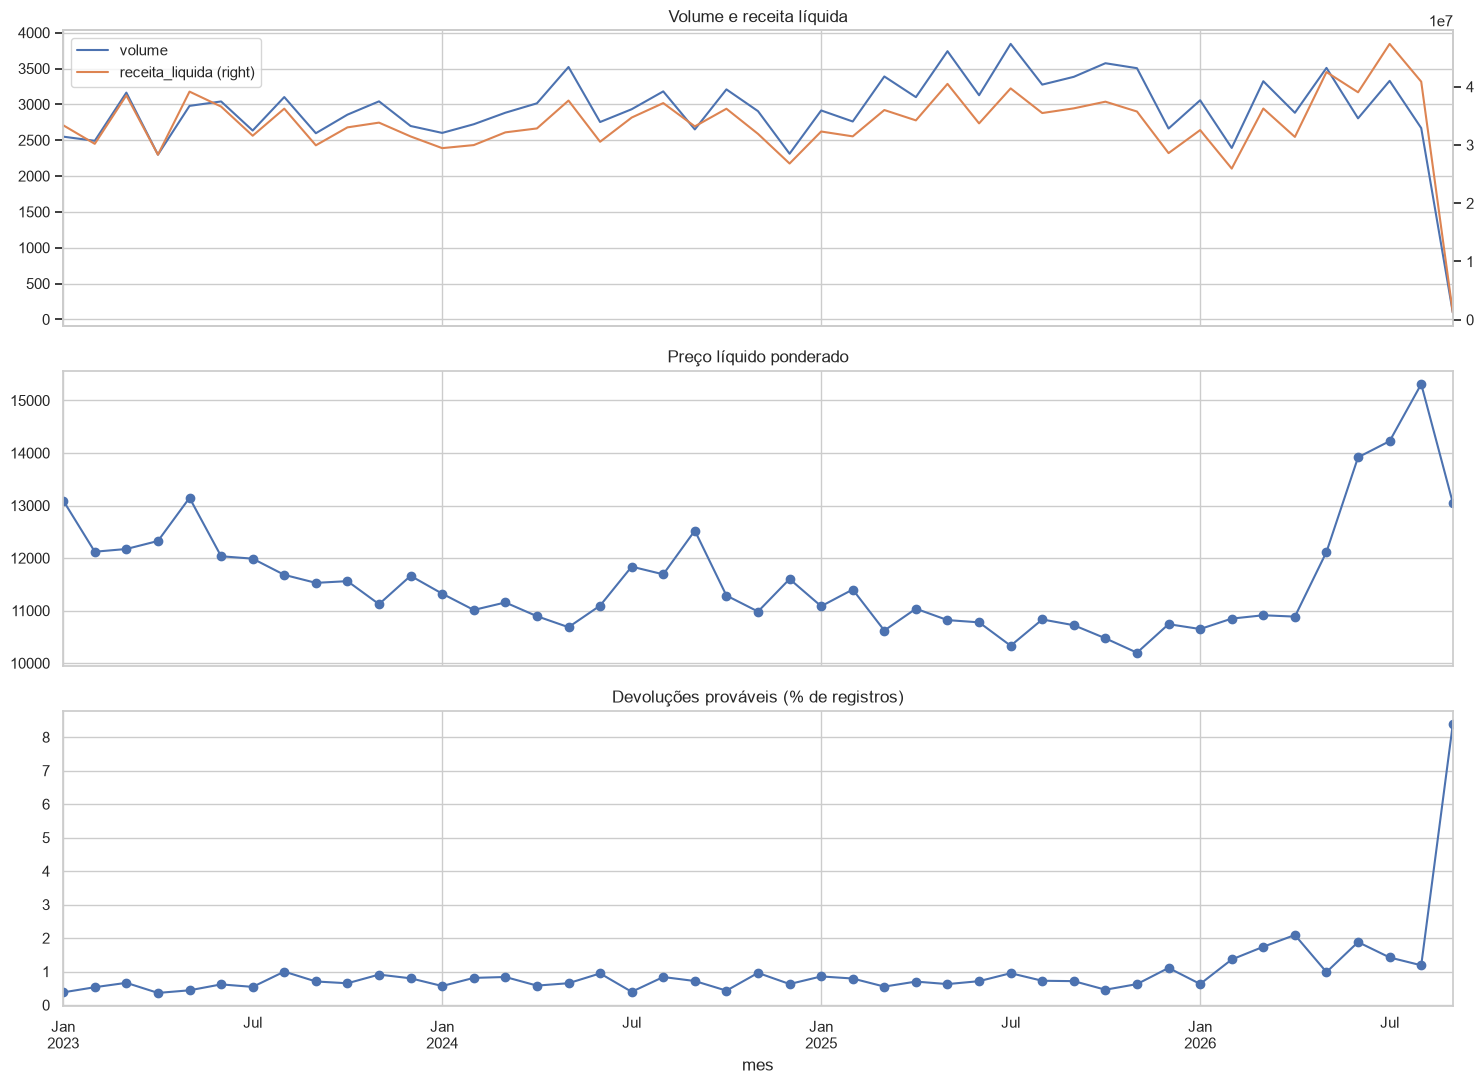

In [12]:
sales_month = (pricing.assign(mes=pricing[DATE_COL].dt.to_period('M').dt.to_timestamp())
    .groupby('mes').agg(registros=('volume','size'), volume=('volume','sum'),
        receita_liquida=('receita_liquida','sum'), lucro_reposicao=('lucro_reposicao','sum')).sort_index())
sales_month['preco_liquido_ponderado'] = sales_month['receita_liquida']/sales_month['volume']
sales_month['margem_pct_ponderada'] = sales_month['lucro_reposicao']/sales_month['receita_liquida']

returns_month = (df.assign(mes=df[DATE_COL].dt.to_period('M').dt.to_timestamp())
    .groupby('mes', observed=True)['tipo_movimento_eda']
    .apply(lambda x: x.eq('DEVOLUCAO_PROVAVEL').mean()).rename('taxa_devolucao_registros'))
monthly = sales_month.join(returns_month)
display(monthly.tail(18))

fig, axes = plt.subplots(3,1,figsize=(15,11),sharex=True)
monthly[['volume','receita_liquida']].plot(ax=axes[0], secondary_y='receita_liquida', title='Volume e receita líquida')
monthly['preco_liquido_ponderado'].plot(ax=axes[1], marker='o', title='Preço líquido ponderado')
monthly['taxa_devolucao_registros'].mul(100).plot(ax=axes[2], marker='o', title='Devoluções prováveis (% de registros)')
plt.tight_layout(); plt.show()

### Conclusão da etapa

O preço líquido ponderado acelera entre maio e agosto/2026, enquanto a margem não cresce na mesma proporção. Isso pode refletir reajuste, aumento de custo ou mudança no mix, e não deve ser atribuído somente a preço sem decomposição adicional. Março e abril/2026 apresentam aumento de devoluções prováveis e merecem investigação. Setembro/2026 contém poucos registros e deve ser identificado como mês incompleto nos gráficos e comparações.

## 8. Cortes comerciais, dispersão e concentração

In [13]:
def pricing_cut(data, dimension, min_records=1):
    result = (data.groupby(dimension, observed=True, dropna=False)
        .agg(registros=('volume','size'), clientes=('Código Cliente','nunique'),
             volume=('volume','sum'), receita_liquida=('receita_liquida','sum'),
             lucro_reposicao=('lucro_reposicao','sum')))
    result = result[result['registros'].ge(min_records)]
    result['preco_liquido_ponderado'] = result['receita_liquida']/result['volume']
    result['margem_pct_ponderada'] = result['lucro_reposicao']/result['receita_liquida']
    return result.sort_values('receita_liquida', ascending=False)

CUTS = ['Canal','Segmentação B2B','Estado Cliente','Estado Base','Prod - Família de Produtos','Prod - Embalagem']
for dimension in CUTS:
    display(Markdown(f'### {dimension}'))
    display(pricing_cut(pricing, dimension).head(20))

### Canal

,registros,clientes,volume,receita_liquida,lucro_reposicao,preco_liquido_ponderado,margem_pct_ponderada
Canal,,,,,,,
COMNAC,245456,7507,131463.69,1.513320e+09,2.293311e+08,11511.312834,0.151542


### Segmentação B2B

,registros,clientes,volume,receita_liquida,lucro_reposicao,preco_liquido_ponderado,margem_pct_ponderada
Segmentação B2B,,,,,,,
OUTRAS INDÚSTRIAS,19807,699,38278.53,3.266046e+08,45924849.86,8532.317173,0.140613
TRANSPORTE DE PASSAG,53194,1104,19580.75,2.552033e+08,33481996.27,13033.377089,0.131197
TRANSPORTE DE CARGAS,49218,1360,18489.25,2.313738e+08,32572404.25,12513.963328,0.140778
CONSTRUÇÃO E CIMENTO,35603,1011,13109.35,1.648611e+08,27089418.61,12575.838640,0.164317
MINERAÇÃO,23498,420,11096.64,1.396756e+08,22356104.81,12587.199557,0.160057
SERVIÇOS,21458,657,7926.18,9.788279e+07,15953943.74,12349.301970,0.162990
TÉRMICA,1204,179,2353.46,4.342478e+07,10089887.85,18451.462557,0.232353
COMÉRCIO,9440,360,3764.26,4.069716e+07,7104904.16,10811.462843,0.174580
GOVERNO,1478,53,3054.75,4.013456e+07,4805312.91,13138.409199,0.119730


### Estado Cliente

...

,registros,clientes,volume,receita_liquida,lucro_reposicao,preco_liquido_ponderado,margem_pct_ponderada
Estado Base,,,,,,,
Rio de Janeiro,35178,1266,53568.80,4.880457e+08,61393943.10,9110.632674,0.125795
São Paulo,47131,1572,17967.11,2.315622e+08,39697091.62,12888.117128,0.171432
Minas Gerais,31151,1154,9810.13,1.246347e+08,18709655.50,12704.696502,0.150116
Ceará,26191,648,7593.10,1.029226e+08,18409629.43,13554.753770,0.178869
Bahia,18724,526,8016.63,1.025763e+08,16023365.21,12795.438217,0.156209
Paraná,16523,559,7159.43,8.723581e+07,14313257.40,12184.742699,0.164075
Goiás,10869,352,5737.74,6.740049e+07,8993235.23,11746.870820,0.133430
Pernambuco,16533,412,4390.54,5.995320e+07,9849444.26,13655.085106,0.164286
Pará,6579,253,3268.45,4.240171e+07,6089046.10,12973.033215,0.143604


### Prod - Família de Produtos

,registros,clientes,volume,receita_liquida,lucro_reposicao,preco_liquido_ponderado,margem_pct_ponderada
Prod - Família de Produtos,,,,,,,
TOP TURBO,40616,4633,27824.34,3.146420e+08,45411034.10,11308.157529,0.144326
AV,1398,364,31874.83,2.305148e+08,27920993.68,7231.875749,0.121125
HYDRA XP,21354,2791,13386.82,1.422225e+08,28759920.04,10624.065931,0.202218
TOP TURBO PRO,8913,1641,4738.12,6.470933e+07,9142452.77,13657.174379,0.141285
GEAR,12472,1373,4737.43,6.133780e+07,11450666.40,12947.484058,0.186682
GL 5,18962,2881,4610.97,5.936161e+07,9183581.44,12873.995808,0.154706
HYDRA,8480,1628,4985.00,5.065131e+07,9191184.51,10160.744487,0.181460
TRM 5,13720,1850,2851.85,4.044186e+07,6087836.93,14180.921398,0.150533
FLUIDO PARA RADIADOR,6296,1043,2148.53,2.872171e+07,3449647.87,13368.073143,0.120106


### Prod - Embalagem

,registros,clientes,volume,receita_liquida,lucro_reposicao,preco_liquido_ponderado,margem_pct_ponderada
Prod - Embalagem,,,,,,,
TAMBOR 200L,86174,4735,50672.60,6.590951e+08,1.062861e+08,13006.933133,0.161261
GRANEL,6196,624,40468.14,3.142335e+08,3.874022e+07,7764.960674,0.123285
BOMBONA 20L,35538,3626,15472.14,1.879497e+08,2.960422e+07,12147.620659,0.157511
BALDE 20L,65441,4517,12397.63,1.629359e+08,2.840395e+07,13142.501953,0.174326
TAMBOR 170KG,11681,2134,3765.64,6.507681e+07,7.967779e+06,17281.739232,0.122437
BALDE 20KG,14870,2378,1670.84,3.170523e+07,4.094801e+06,18975.625877,0.129152
CONTENTOR 1000L,1149,207,2370.00,3.163472e+07,3.957099e+06,13347.983494,0.125087
CX 24 x 1L,14440,1491,2370.05,3.136048e+07,5.134509e+06,13231.991671,0.163725
TAMBOR ESP,988,327,1446.40,1.509416e+07,2.684402e+06,10435.673935,0.177844


In [14]:
pricing['mes'] = pricing[DATE_COL].dt.to_period('M')
product_month = (pricing.groupby(['Código Material','Material','mes'], observed=True)
    .agg(registros=('volume','size'), clientes=('Código Cliente','nunique'), volume=('volume','sum'),
         receita_liquida=('receita_liquida','sum'), preco_mediano=('preco_liquido_unitario','median'),
         preco_p10=('preco_liquido_unitario',lambda x:x.quantile(.10)),
         preco_p90=('preco_liquido_unitario',lambda x:x.quantile(.90))))
product_month['preco_ponderado'] = product_month['receita_liquida']/product_month['volume']
product_month['dispersao_p90_p10'] = product_month['preco_p90']-product_month['preco_p10']
display(product_month.query('registros >= 30').sort_values('dispersao_p90_p10',ascending=False).head(30))

registros  \
Código Material Material                                mes                  
1014421         LUBRAX GOLD XP 75W80 - BL 20 L          2023-11         42   
                                                        2023-08         39   
                                                        2023-05         38   
                                                        2023-04         31   
1020457         LUBRAX TRM 235.12 - TB 200 L            2024-09         36   
1000623         LUBRAX AUTOLITH 2 - BL 20 K             2026-07         32   
1020457         LUBRAX TRM 235.12 - TB 200 L            2025-08         38   
1002242         LUBRAX LITH EP 2  - TB 170 K            2026-07         39   
1024130         LUBRAX VALORA OFFROAD - CXC24F1L        2023-07         38   
1000743         LUBRAX LITHPLUS EP 2 - BL 20 K          2026-07         97   
1014421         LUBRAX GOLD XP 75W80 - BL 20 L          2026-06         72   
                                                        2026-05         83   
1001969         LUBRAX GL 5 85W140 - TB 200 L           2026-06         59   
1002256         LUBRAX LITHPLUS EP 2 - TB 170 K         2026-07         61   
1024130         LUBRAX VALORA OFFROAD - CXC24F1L        2023-08         30   
1014421         LUBRAX GOLD XP 75W80 - BL 20 L          2025-12         40   
1026906         LUBRAX ATF TA - 24x1L                   2026-07         46   
1026716         LUBRAX TOP AUTO 5W30 C2,C3 SINT-24x1L   2026-05         35   
1026906         LUBRAX ATF TA - 24x1L                   2026-06         34   
1000743         LUBRAX LITHPLUS EP 2 - BL 20 K          2025-03         77   
1001981         LUBRAX FLUIDO P/ FREIOS ESP - CX40F1/2L 2025-04         41   
1002248         LUBRAX CHASSIS 2  - TB 170 K            2026-07         39   
1014421         LUBRAX GOLD XP 75W80 - BL 20 L          2026-07         68   
1002077         LUBRAX ATF TA - CXC24 F1L               2023-03         44   
1020457         LUBRAX TRM 235.12 - TB 200 L            2024-12         32   
1002077         LUBRAX ATF TA - CXC24 F1L               2023-09         66   
1026155         LUBRAX VALORA SP 5W30 - CXC24F1L        2025-07         30   
1024130         LUBRAX VALORA OFFROAD - CXC24F1L        2023-05         33   
1020457         LUBRAX TRM 235.12 - TB 200 L            2025-07         44   
1020027         LUBRAX VALORA SN PLUS 5W30 - CXC24F1L   2023-12         30   

                                                                 clientes  \
Código Material Material                                mes                 
1014421         LUBRAX GOLD XP 75W80 - BL 20 L          2023-11        42   
                                                        2023-08        39   
                                                        2023-05        38   
                                                        2023-04        31   
1020457         LUBRAX TRM 235.12 - TB 200 L            2024-09        36   
1000623         LUBRAX AUTOLITH 2 - BL 20 K             2026-07        32   
1020457         LUBRAX TRM 235.12 - TB 200 L            2025-08        38   
1002242         LUBRAX LITH EP 2  - TB 170 K            2026-07        39   
1024130         LUBRAX VALORA OFFROAD - CXC24F1L        2023-07        38   
1000743         LUBRAX LITHPLUS EP 2 - BL 20 K          2026-07        96   
1014421         LUBRAX GOLD XP 75W80 - BL 20 L          2026-06        72   
                                                        2026-05        83   
1001969         LUBRAX GL 5 85W140 - TB 200 L           2026-06        59   
1002256         LUBRAX LITHPLUS EP 2 - TB 170 K         2026-07        61   
1024130         LUBRAX VALORA OFFROAD - CXC24F1L        2023-08        30   
1014421         LUBRAX GOLD XP 75W80 - BL 20 L          2025-12        40   
1026906         LUBRAX ATF TA - 24x1L                   2026-07        46   
1026716         LUBRAX TOP AUTO 5W30 C2,C3 SINT-24x1L   2026-05        35   
1026906         LUBRAX ATF T

,Código Cliente,Nome Cliente,receita_acumulada_pct,posicao
0,15314,I.T.B. - EQUIPAMENTOS ELETRICOS LTD,0.056265,1
1,13897,TRAEL TRANSFORMADORES ELETRICOS LTD,0.078870,2
2,1473,COMANDO DA MARINHA,0.098601,3
3,19896,ROMAGNOLE PRODUTOS ELETRICOS S.A.,0.110256,4
4,1164412,AZULAO GERACAO DE ENERGIA S.A.,0.121702,5
5,14475,MINERACAO SERRA GRANDE S A,0.131944,6
6,9200,TRANSPORTADORA DE DIESEL CAVALO MAR,0.141333,7
7,94318,TRANSFORMADORES E SERVICOS DE ENERG,0.150204,8
8,22793,INDUSTRIA DE TRANSFORMADORES AMAZON,0.158801,9
9,14509,MINERACAO CARAIBA S/A,0.167227,10


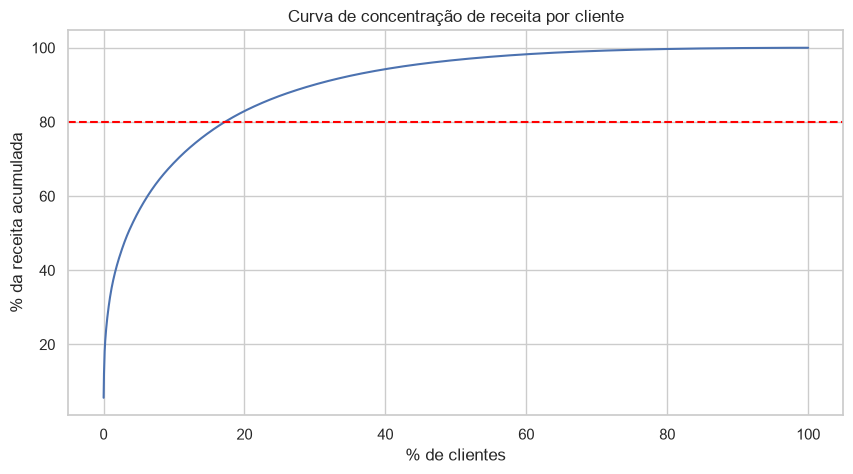

In [15]:
customer_revenue = pricing.groupby(['Código Cliente','Nome Cliente'], observed=True)['receita_liquida'].sum().sort_values(ascending=False)
customer_share = customer_revenue/customer_revenue.sum()
customer_curve = customer_share.cumsum().reset_index(name='receita_acumulada_pct')
customer_curve['posicao'] = np.arange(1,len(customer_curve)+1)
display(customer_curve.head(20))
plt.figure(figsize=(10,5))
plt.plot(customer_curve['posicao']/len(customer_curve)*100, customer_curve['receita_acumulada_pct']*100)
plt.axhline(80,color='red',ls='--'); plt.xlabel('% de clientes'); plt.ylabel('% da receita acumulada')
plt.title('Curva de concentração de receita por cliente'); plt.show()

### Conclusão da etapa

`Canal` é constante neste recorte e, portanto, não explica diferenças de preço. Segmento B2B, família, embalagem, estado do cliente e base apresentam diferenças relevantes de preço e margem, mas parte delas decorre do mix de produtos. A análise produto-mês é um benchmark mais comparável. O maior cliente responde por cerca de 5,63% da receita e os 20 maiores por 21,67%, indicando concentração relevante, mas não dependência de um único cliente.

## 9. Dataset agregado para K-Means

A unidade escolhida é cliente. Preços são ponderados; devoluções e ajustes entram como taxas/valores agregados, não como preços de venda.

In [16]:
customer_features = (pricing.groupby('Código Cliente', observed=True)
    .agg(nome_cliente=('Nome Cliente','first'), transacoes=('volume','size'), meses_ativos=(DATE_COL,lambda x:x.dt.to_period('M').nunique()),
         produtos=('Código Material','nunique'), volume_total=('volume','sum'),
         receita_liquida_total=('receita_liquida','sum'), lucro_reposicao_total=('lucro_reposicao','sum'),
         volume_medio=('volume','mean'), volume_std=('volume','std'), ultima_compra=(DATE_COL,'max')).reset_index())
customer_features['preco_liquido_ponderado'] = customer_features['receita_liquida_total']/customer_features['volume_total']
customer_features['margem_pct_ponderada'] = customer_features['lucro_reposicao_total']/customer_features['receita_liquida_total']
customer_features['frequencia_mensal'] = customer_features['transacoes']/customer_features['meses_ativos']
customer_features['cv_volume'] = customer_features['volume_std']/customer_features['volume_medio'].replace(0,np.nan)

movement_customer = (df.groupby('Código Cliente', observed=True)
    .agg(registros_totais=('tipo_movimento_eda','size'),
         devolucoes=('tipo_movimento_eda',lambda x:x.eq('DEVOLUCAO_PROVAVEL').sum()),
         ajustes=('tipo_movimento_eda',lambda x:x.eq('AJUSTE_SEM_VOLUME').sum()),
         inconsistencias=('tipo_movimento_eda',lambda x:x.eq('SINAL_INCONSISTENTE').sum())).reset_index())
customer_features = customer_features.merge(movement_customer,on='Código Cliente',how='left')
customer_features['taxa_devolucao'] = customer_features['devolucoes']/customer_features['registros_totais']
customer_features['taxa_ajuste'] = customer_features['ajustes']/customer_features['registros_totais']
customer_features['taxa_inconsistencia'] = customer_features['inconsistencias']/customer_features['registros_totais']
customer_features.replace([np.inf,-np.inf],np.nan,inplace=True)

display(customer_features.describe(include='all').T)
customer_features.to_pickle(OUTPUT_DIR/'kmeans_clientes_features.pkl')
customer_features.to_csv(OUTPUT_DIR/'kmeans_clientes_features.csv',index=False,encoding='utf-8-sig')
print(f'Dataset salvo: {len(customer_features):,} clientes × {customer_features.shape[1]} colunas')

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Código Cliente,7507.0,NaN,NaN,NaN,962503.836819,211.0,108176.0,1116649.0,1753426.5,1914915.0,761524.284962
nome_cliente,7507,5225,"ARMAC LOCACAO, LOGISTICA E SERVICOS",155,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transacoes,7507.0,NaN,NaN,NaN,32.69695,1.0,3.0,11.0,36.0,1338.0,58.512168
meses_ativos,7507.0,NaN,NaN,NaN,10.902491,1.0,2.0,6.0,16.0,45.0,11.766325
produtos,7507.0,NaN,NaN,NaN,7.97509,1.0,2.0,5.0,11.0,153.0,9.26471
volume_total,7507.0,NaN,NaN,NaN,17.512147,0.01,0.79,3.0,10.97,12539.06,168.67664
receita_liquida_total,7507.0,NaN,NaN,NaN,201587.806293,124.77,10224.545,38939.63,141156.97,85147324.3,1286338.570211
lucro_reposicao_total,7507.0,NaN,NaN,NaN,30548.961657,-155113.68,1404.825,5918.42,21106.48,8342240.34,160396.318332
volume_medio,7507.0,NaN,NaN,NaN,0.622413,0.01,0.148127,0.235506,0.418258,272.588261,4.278397
volume_std,6549.0,NaN,NaN,NaN,0.446395,0.0,0.081692,0.153883,0.327005,112.892631,2.516192


Dataset salvo: 7,507 clientes × 22 colunas


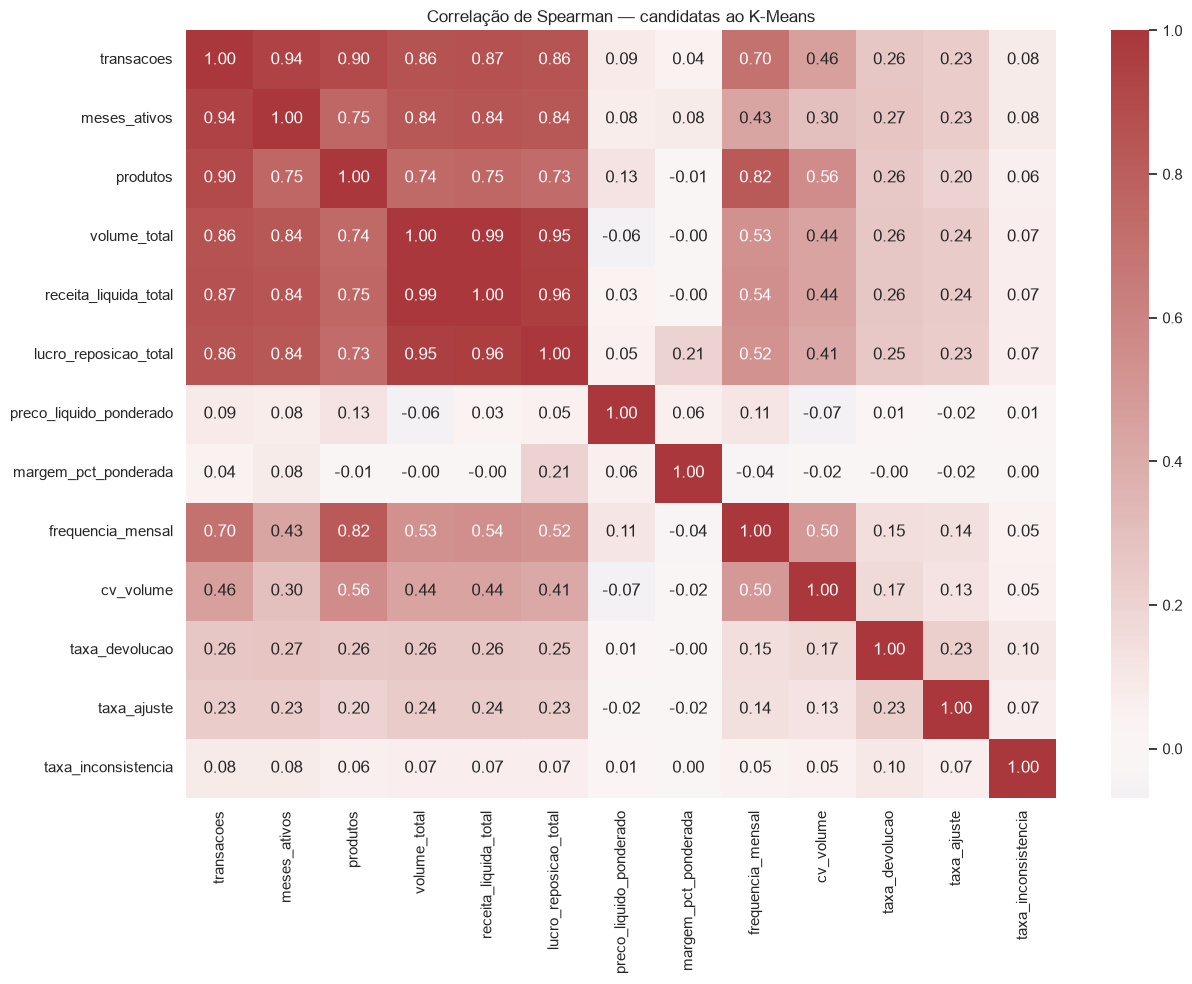

,variavel_a,variavel_b,correlacao
2,volume_total,receita_liquida_total,0.993474
4,receita_liquida_total,lucro_reposicao_total,0.961870
3,volume_total,lucro_reposicao_total,0.954632
0,transacoes,meses_ativos,0.938521
1,transacoes,produtos,0.900978


In [17]:
MODEL_CANDIDATES = ['transacoes','meses_ativos','produtos','volume_total','receita_liquida_total',
    'lucro_reposicao_total','preco_liquido_ponderado','margem_pct_ponderada','frequencia_mensal',
    'cv_volume','taxa_devolucao','taxa_ajuste','taxa_inconsistencia']
corr = customer_features[MODEL_CANDIDATES].corr(method='spearman')
plt.figure(figsize=(13,10))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='vlag',center=0)
plt.title('Correlação de Spearman — candidatas ao K-Means'); plt.tight_layout(); plt.show()

redundant = []
for i,left in enumerate(corr.columns):
    for right in corr.columns[i+1:]:
        if abs(corr.loc[left,right]) >= .90:
            redundant.append({'variavel_a':left,'variavel_b':right,'correlacao':corr.loc[left,right]})
display(pd.DataFrame(redundant).sort_values('correlacao',key=abs,ascending=False) if redundant else pd.DataFrame())

### Conclusão da etapa

O dataset final representa 7.507 clientes com 22 atributos. Antes do K-Means, é necessário reduzir redundância: volume total e receita líquida têm correlação de Spearman de 0,993; receita e lucro, 0,962; volume e lucro, 0,955; transações e meses ativos, 0,939. Usar todas essas variáveis simultaneamente daria peso excessivo ao porte do cliente. A seleção final deve equilibrar porte, preço, margem, frequência, diversidade e comportamento de devolução.

## 10. Critérios de aceite e pendências

In [18]:
acceptance = pd.DataFrame([
    {'criterio':'Todas as linhas classificadas','resultado':df['tipo_movimento_eda'].notna().all()},
    {'criterio':'Nenhum preço calculado com volume zero','resultado':pricing['volume'].gt(EPS).all()},
    {'criterio':'Devoluções fora da tabela de preços','resultado':~pricing['tipo_movimento_eda'].eq('DEVOLUCAO_PROVAVEL').any()},
    {'criterio':'Reconciliações monitoradas','resultado':len(reconciliation_summary)>0},
    {'criterio':'Dataset de clientes sem chaves duplicadas','resultado':~customer_features['Código Cliente'].duplicated().any()},
])
display(acceptance)
assert acceptance['resultado'].all(), 'Há critérios de aceite não atendidos.'

display(Markdown(f'''
### Resumo executivo

- **{len(df):,}** registros foram classificados.
- **{df['tipo_movimento_eda'].eq('DEVOLUCAO_PROVAVEL').sum():,}** são devoluções prováveis.
- **{df['tipo_movimento_eda'].eq('AJUSTE_SEM_VOLUME').sum():,}** são ajustes sem volume.
- **{len(anomalies):,}** têm sinais inconsistentes e foram exportados para auditoria.
- **{len(pricing):,}** vendas elegíveis compõem o EDA de preços.
- O dataset de K-Means possui **{len(customer_features):,} clientes**.
- Resultados gravados em `{OUTPUT_DIR.relative_to(ROOT)}`.

### Validações de negócio ainda necessárias

1. Confirmar se os movimentos negativos representam devolução/estorno.
2. Definir a receita bruta canônica e explicar a diferença entre `Receita Bruta` e `.Receita Bruta`.
3. Explicar a diferença entre `CPV Fechamento` e `.CPV Contábil`.
4. Confirmar as convenções de sinal de desconto, impostos, frete e encargos.

> `Volume` já foi confirmado como **m³** (seção 5, Conclusão da etapa).
'''.replace(',', '.')))


,criterio,resultado
0,Todas as linhas classificadas,True
1,Nenhum preço calculado com volume zero,True
2,Devoluções fora da tabela de preços,True
3,Reconciliações monitoradas,True
4,Dataset de clientes sem chaves duplicadas,True



### Resumo executivo

- **253.624** registros foram classificados.
- **2.068** são devoluções prováveis.
- **1.292** são ajustes sem volume.
- **41** têm sinais inconsistentes e foram exportados para auditoria.
- **245.456** vendas elegíveis compõem o EDA de preços.
- O dataset de K-Means possui **7.507 clientes**.
- Resultados gravados em `outputs\1. EDA`.

### Validações de negócio ainda necessárias

1. Confirmar se os movimentos negativos representam devolução/estorno.
2. Definir a receita bruta canônica e explicar a diferença entre `Receita Bruta` e `.Receita Bruta`.
3. Explicar a diferença entre `CPV Fechamento` e `.CPV Contábil`.
4. Confirmar as convenções de sinal de desconto. impostos. frete e encargos.

> `Volume` já foi confirmado como **m³** (seção 5. Conclusão da etapa).


### Conclusão final

Todos os critérios técnicos de aceite foram atendidos: todas as linhas receberam classificação, nenhum preço foi calculado com volume zero, devoluções ficaram fora da população de preços, as reconciliações foram monitoradas e o dataset de clientes não possui códigos duplicados. Isso valida o processamento técnico, mas não substitui as confirmações de negócio sobre devoluções, unidade de volume e definições contábeis.